problem statement ------> i need to build a system where input is user asks query like what is the good match for this saree or blouse or pant or shirt which is best i need find using rules of fashion meaning this color matches this this one 



how i need to approach it i need to use fashion rule books forit or directly usa an llm to generate output without using rag since it is trained all datasets 

now input should be query+image this should be properly sent to an llm with rag or direct llm with proper prompt saying these are my 

how i need to handle input take opensorce model which is multimodal like kimi 2.6 or any other model now generate repsonse directly with rag or without rag 

this approach is totally llm dependent

one more approach extract dominant colors from the image  usig opencv then send this colors to prompt then send to llm 



In [8]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(813.5), np.float64(1099.5), np.float64(-0.5))

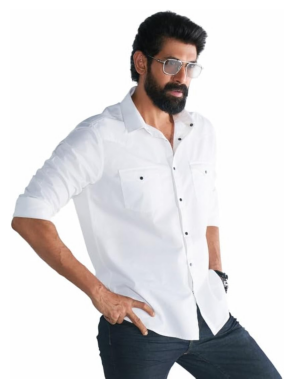

In [49]:
image = cv2.imread("dataset/41NXuXZOxQL._AC_UY1100_.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")

In [50]:
image = cv2.resize(image, (200, 200))

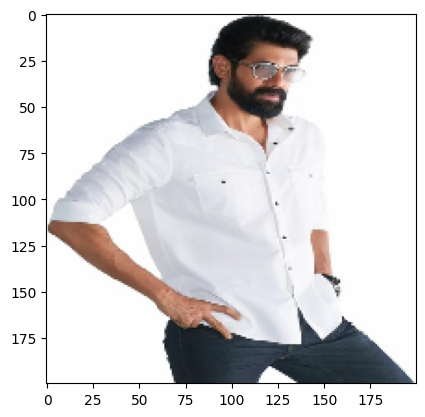

In [51]:
plt.imshow(image)

In [52]:
h, w, _ = image.shape
image = image[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]

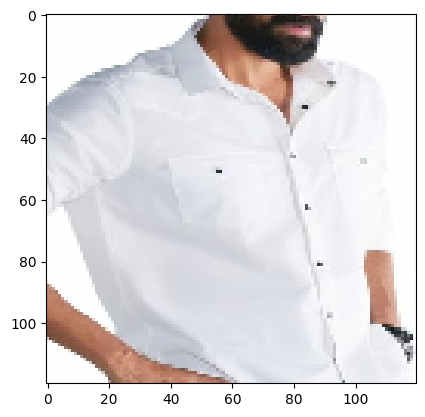

In [53]:
plt.imshow(image)

In [55]:
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

lower_skin = np.array([0, 20, 70])
upper_skin = np.array([20, 255, 255])
skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

image[skin_mask > 0] = [0, 0, 0]

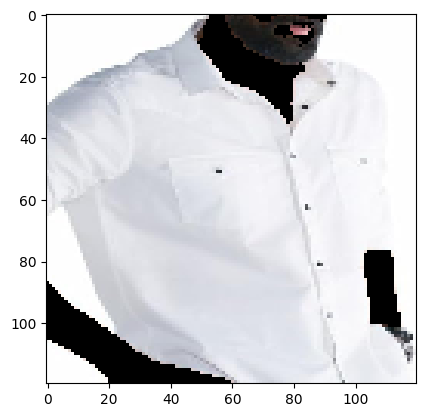

In [56]:
plt.imshow(image)

In [57]:
lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 30, 255])
white_mask = cv2.inRange(hsv, lower_white, upper_white)

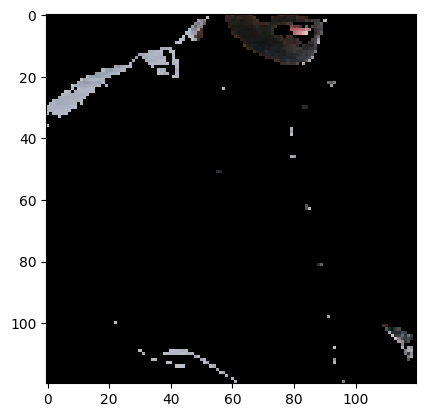

In [58]:
image[white_mask> 0] = [0, 0, 0]
plt.imshow(image)

In [59]:
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 50])
black_mask = cv2.inRange(hsv, lower_black, upper_black)

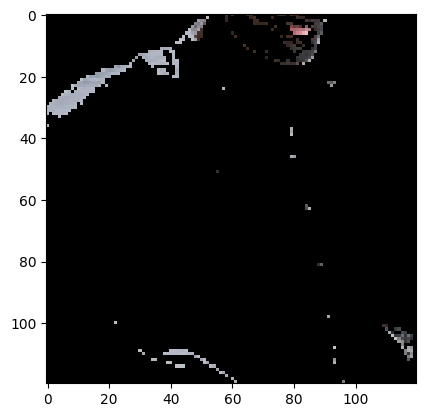

In [60]:
image[black_mask> 0] = [0, 0, 0]
plt.imshow(image)

In [61]:
pixels = image.reshape(-1, 3)
pixels = pixels[np.any(pixels != [0, 0, 0], axis=1)]

kmeans = KMeans(n_clusters=3, n_init=7)
kmeans.fit(pixels)

colors = kmeans.cluster_centers_

In [62]:
colors

array([[173.38062284, 176.5017301 , 187.64359862],
       [ 62.92198582,  54.4751773 ,  53.35460993],
       [137.34210526, 121.39473684, 127.13157895]])

In [63]:
hex_colors = [
    '#%02x%02x%02x' % tuple(map(int, c))
    for c in colors
]

print(hex_colors)

['#adb0bb', '#3e3635', '#89797f']


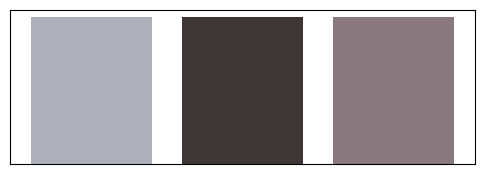

In [64]:
plt.figure(figsize=(6, 2))

for i, color in enumerate(hex_colors):
    plt.bar(i, 1, color=color)

plt.xticks([])
plt.yticks([])
plt.show()

In [65]:

PROMPT_TEMPLATE = """
You are an expert fashion stylist AI.

TASK:
Based on the given color palette and user query, suggest matching outfit recommendations.

USER QUERY:
{user_query}

DETECTED COLORS (from the clothing image):
{colors}

INSTRUCTIONS:

- Do NOT assume access to the image
- Use the provided colors as the source of truth
- If clothing type is unclear, make a reasonable assumption (e.g., shirt, dress, etc.)

- Respond in a natural paragraph format (NOT JSON)
- First briefly describe the color palette
- Then give 3 matching recommendations

Each recommendation must include:
- item
- color name + hex code
- reason
- confidence (0 to 1)

Keep the response clear, practical, and stylist-like.
"""

In [66]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os 
load_dotenv()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
    temperature=0.3
)

In [67]:
query="what matching thing i need to wear for this shirt"

In [68]:
colors=hex_colors

In [69]:
prompt = PROMPT_TEMPLATE.format(
            user_query=query,
            colors=", ".join(colors) if colors else "Not provided"
        )

In [70]:
response = llm.invoke([
            HumanMessage(content=prompt)
        ])

In [71]:
response

AIMessage(content='The shirt’s palette blends a soft, cool‑gray‑blue (#adb0bb), a deep, earthy charcoal brown (#3e3635), and a muted, dusty mauve‑gray (#89797f). The overall vibe is understated and sophisticated, with just enough warmth from the brown to balance the cooler tones.\n\n**1. Tailored trousers – Charcoal Brown (#3e3635)**  \nA pair of slim‑fit chinos or wool trousers in the same deep charcoal brown creates a seamless, tonal look that grounds the lighter gray‑blue of the shirt while echoing the darker accents in the palette. This monochromatic pairing feels polished yet relaxed. **Confidence: 0.92**\n\n**2. Light‑weight blazer – Dusty Mauve Gray (#89797f)**  \nA structured blazer in the muted mauve‑gray adds a subtle pop of color without clashing, tying together the shirt’s cooler undertones and the brown accents. The soft hue works especially well for smart‑casual settings, offering depth and a touch of elegance. **Confidence: 0.88**\n\n**3. Leather loafers – Soft Gray‑Blue

In [12]:
import io
from rembg import remove
from PIL import Image


(np.float64(-0.5), np.float64(813.5), np.float64(1099.5), np.float64(-0.5))

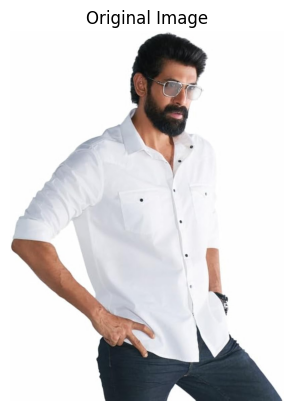

In [13]:
image_path = "dataset/41NXuXZOxQL._AC_UY1100_.jpg"

with open(image_path, "rb") as f:
    image_bytes = f.read()

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(813.5), np.float64(1099.5), np.float64(-0.5))

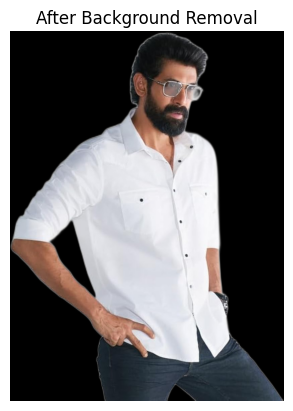

In [14]:
output = remove(image_bytes)

seg_image = Image.open(io.BytesIO(output)).convert("RGB")
seg_image = np.array(seg_image)

plt.imshow(seg_image)
plt.title("After Background Removal")
plt.axis("off")

In [33]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
from rembg import remove
from PIL import Image
import io


def extract_colors_from_bytes(image_bytes, k=3):
   
    output = remove(image_bytes)

    image = Image.open(io.BytesIO(output)).convert("RGB")
    image = np.array(image)

    image = cv2.resize(image, (300, 300))


    pixels = image.reshape(-1, 3)

  
    pixels = pixels[np.any(pixels > [10, 10, 10], axis=1)]

    if len(pixels) < k:
        return [{"hex": "#000000", "percentage": 100.0}]


    if len(pixels) > 5000:
        idx = np.random.choice(len(pixels), 5000, replace=False)
        pixels = pixels[idx]

    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_
    counts = np.bincount(kmeans.labels_)
    total = counts.sum()


    sorted_data = sorted(zip(counts, colors), reverse=True)


    result = []
    for count, color in sorted_data:
        hex_code = '#%02x%02x%02x' % tuple(map(int, color))
        percent = (count / total) * 100

        result.append({
            "hex": hex_code,
            "percentage": round(percent, 2)
        })

    return result

In [34]:
image_path = "dataset/41NXuXZOxQL._AC_UY1100_.jpg"

with open(image_path, "rb") as f:
    image_bytes = f.read()

result=extract_colors_from_bytes(image_bytes)  
print(result)  

[{'hex': '#dedfe5', 'percentage': np.float64(60.0)}, {'hex': '#2a2f35', 'percentage': np.float64(24.66)}, {'hex': '#9e7464', 'percentage': np.float64(15.34)}]


In [38]:
colors = ['#dedfe5','#2a2f35']

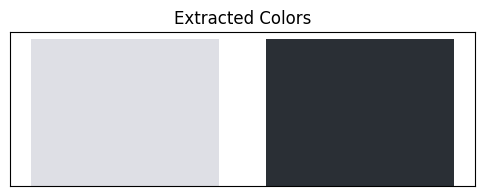

In [39]:
plt.figure(figsize=(6, 2))

for i, color in enumerate(colors):
    plt.bar(i, 1, color=color)

plt.title("Extracted Colors")
plt.xticks([])
plt.yticks([])
plt.show()